### 1. Configuração do Ecossistema de Data Science
Nesta célula inicial, preparamos o ambiente de desenvolvimento importando as bibliotecas fundamentais para o processamento de dados e inteligência artificial do projeto **PlaySafe4All**:

* **Manipulação de Dados (`Pandas` & `NumPy`)**: Essenciais para a estruturação das tabelas biomecânicas e cálculos matemáticos de alta performance.
* **Gestão de Sistema (`OS` & `Time`)**: Permitem a localização dinâmica de ficheiros em diferentes sistemas operativos e a medição do tempo de resposta do algoritmo.
* **Algoritmos de Previsão (`XGBoost`)**: O motor de decisão que utiliza *Gradient Boosting* para identificar padrões de risco de entorse.
* **Ecossistema `Scikit-Learn`**:
    * **Divisão de Dados**: Para separar amostras de treino e de teste.
    * **Normalização**: Garante que variáveis com unidades diferentes (ex: tempo vs. força) sejam interpretadas com a mesma importância.
    * **Métricas de Avaliação**: Ferramentas para medir a precisão e, crucialmente, o **Recall** (segurança do atleta).

In [1]:
# ==============================================================================
# CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÃO DA SEMENTE GLOBAL
# Responsabilidade: Carregar ferramentas de Manipulação, ML e Gráficos para RF.
# ==============================================================================
import pandas as pd
import numpy as np
import os
import random

# 1. Visualização de Dados (Para Gráficos de Importância de Atributos e Matrizes)
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Machine Learning Tradicional e Validação Cruzada (Scikit-Learn)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_auc_score)

# ==============================================================================
# CONFIGURAÇÕES DE REPRODUTIBILIDADE CIENTÍFICA (CRUCIAL PARA O JÚRI)
# ==============================================================================
def definir_semente_global(seed=42):
    """Garante que os resultados do Random Forest sejam idênticos em cada execução."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

definir_semente_global(42)

# Configurações Estéticas para o Relatório/Artigo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100  # Melhora a resolução dos gráficos para colar no Word

print("🚀 Todas as bibliotecas necessárias para o Random Forest foram carregadas!")

🚀 Todas as bibliotecas necessárias para o Random Forest foram carregadas!


### 2. Aquisição e Consolidação de Dados Biomecânicos
Nesta etapa, o sistema estabelece a ligação com a diretoria externa `Data` para importar os três conjuntos de dados que servem de base ao estudo.

* **Caminhos Dinâmicos**: Utilizamos o `os.path.join` com caminhos relativos (`../Data`). Isto garante que o projeto é multiplataforma, funcionando corretamente quer o "stor" o execute em Windows, Mac ou Linux.
* **Gestão de Erros (Try-Except)**: Implementámos uma estrutura de controlo para capturar erros de localização de ficheiros. Se a pasta ou os CSVs estiverem em falta, o sistema informa o utilizador em vez de interromper o programa abruptamente.
* **Métrica de Volume**: Após o carregamento bem-sucedido, o sistema calcula e apresenta o somatório total de amostras disponíveis, permitindo uma primeira validação visual da integridade dos dados.

In [2]:
# ==============================================================================
# CÉLULA 2: CARREGAMENTO DE DADOS (APENAS O DATASET FINAL)
# Responsabilidade: Aceder à pasta 'Data' e carregar o ficheiro unificado seguro.
# ==============================================================================
import os
import pandas as pd

print("--- FASE 1: CARREGAMENTO ---")

# Caminho absoluto direto do teu Desktop que foi validado
BASE_PATH = r"C:\Users\User\Desktop\escola\Projeto\PlaySafe4All\PlaySafe4All\Data"
NOME_FICHEIRO = "Dataset_Unificado_Final.csv"
CAMINHO_COMPLETO = os.path.join(BASE_PATH, NOME_FICHEIRO)

load_successful = False

try:
    # Leitura direta com encoding 'latin1' para aceitar acentos e cedilhas do Windows
    df_unificado = pd.read_csv(CAMINHO_COMPLETO, sep=None, engine='python', encoding='latin1')
    
    print(f"✅ Ficheiro '{NOME_FICHEIRO}' carregado com sucesso!")
    print(f"   ↳ Total de atletas (Linhas): {df_unificado.shape[0]}")
    print(f"   ↳ Total de atributos (Colunas): {df_unificado.shape[1]}")
    
    load_successful = True

except FileNotFoundError:
    print(f"❌ ERRO: Não encontrei o ficheiro '{NOME_FICHEIRO}'")
    print(f"   Caminho verificado: {CAMINHO_COMPLETO}")
    load_successful = False
    
except Exception as e:
    print(f"❌ ERRO ao ler o ficheiro: {str(e)}")
    load_successful = False

--- FASE 1: CARREGAMENTO ---
✅ Ficheiro 'Dataset_Unificado_Final.csv' carregado com sucesso!
   ↳ Total de atletas (Linhas): 61
   ↳ Total de atributos (Colunas): 13


# 3. Pré-Processamento e Configuração da Validação Cruzada (Random Forest)

Esta célula realiza o isolamento da variável-alvo (`TARGET_INJURY`) e a estruturação da matriz de atributos preditores físicos para o algoritmo **Random Forest**. O objetivo principal é garantir um pipeline limpo, focado na consistência dos dados e na prevenção de falhas de generalização.

###  Operações Realizadas:
* **Limpeza de Identificadores:** Eliminação de variáveis nominativas ou de registo administrativo (`Numero`, `ID`, `Atleta`) que poderiam enviesar ou confundir o algoritmo com padrões não-físicos.
* **Mapeamento de Features Biomecânicas:** Extração dos atributos de carga, exposição e desempenho físico (`T0_T1_Match_Time_exposure`, `T0_T1_Training_Time_exposure`, `T0SRTMax`, `T0TTestMin`, `T0SJmMax`, `T0Veli`).
* **Tratamento de Dados Omissos por Mediana:** Imputação de valores nulos utilizando a mediana local de cada coluna. Esta estratégia é estatisticamente robusta para modelos baseados em árvores de decisão, pois não introduz valores atípicos (*outliers*) que possam distorcer os pontos de corte (*splits*) nas ramificações das árvores.

###  Blindagem Metodológica (Prevenção de Data Leakage):
Para evitar o fenómeno de **Data Leakage** (vazamento de informação), nenhum escalonamento ou normalização global é aplicado nesta fase. A matriz $X$ permanece no seu formato original. O processo de transformação dos dados será feito exclusivamente de forma dinâmica dentro de cada iteração da validação cruzada.

A integridade do pipeline é selada com a configuração da **Validação Cruzada Estratificada em 10 Blocos (Stratified 10-Fold CV)**. Como o algoritmo Random Forest constrói múltiplos estimadores de forma aleatória, este motor de amostragem estratificada garante que cada um dos 10 subconjuntos de teste retenha a exata proporção original entre atletas saudáveis (classe maioritária) e em risco (classe minoritária), forçando uma avaliação rigorosa, realista e altamente reprodutível.

In [3]:
# ==============================================================================
# CÉLULA 3: PRÉ-PROCESSAMENTO (ESTRUTURA PARA VALIDAÇÃO CRUZADA DO RANDOM FOREST)
# Responsabilidade: Preparar a matriz X e o vetor y usando TARGET_INJURY.
# ==============================================================================
from sklearn.model_selection import StratifiedKFold
import pandas as pd

print("\n--- FASE 2: PREPARAÇÃO DE DADOS (ABORDAGEM CROSS-VALIDATION) ---")

if 'df_unificado' not in locals():
    print("❌ ERRO: Precisa de correr a CÉLULA 2 com sucesso primeiro!")
else:
    # 1. Usar a base unificada carregada na Célula 2
    df = df_unificado.copy()
    df.columns = df.columns.str.strip()

    # Remover colunas de identificação se existirem no ficheiro
    for col_to_drop in ['Numero', 'ID', 'Atleta']:
        if col_to_drop in df.columns:
            df.drop(columns=[col_to_drop], inplace=True)

    # 2. Definir o nome exato da coluna Alvo com base no seu print
    TARGET_COL = 'TARGET_INJURY'

    if TARGET_COL not in df.columns:
        raise KeyError(f"❌ ERRO: A coluna '{TARGET_COL}' não foi encontrada no dataset. Verifique maiúsculas/minúsculas.")

    # 3. SELEÇÃO DE ATRIBUTOS PREDITORES (Features)
    # Lista com as métricas físicas e de exposição principais do projeto
    FEATURES = ['T0_T1_Match_Time_exposure', 'T0_T1_Training_Time_exposure', 'T0SRTMax', 'T0TTestMin', 'T0SJmMax', 'T0Veli']
    
    # Garantir que usamos apenas as colunas da lista que realmente existem no ficheiro
    features_existentes = [col for col in FEATURES if col in df.columns]
    print(f"🔄 Atributos físicos selecionados: {len(features_existentes)} de {len(FEATURES)}")

    # Isolar a matriz X apenas com as características físicas e converter para números
    X = df[features_existentes].apply(pd.to_numeric, errors='coerce')
    
    # Preencher qualquer valor em falta (NaN) com a mediana de cada coluna (Robusto para árvores)
    X = X.fillna(X.median(numeric_only=True))

    # Isolar o vetor y com o alvo binário puro (0 e 1)
    y = df[TARGET_COL].astype(int)

    # 4. CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA ESTRATIFICADA (10 FOLDS)
    # Não fazemos o escalonamento global aqui para evitar contaminação (Data Leakage).
    # O StandardScaler será aplicado bloco a bloco dentro do loop da Célula 4.
    cv_estrategia = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    print(f"✅ Dados prontos para o Random Forest!")
    print(f"   ↳ Matriz Completa de Atributos (X): {X.shape}")
    print(f"   ↳ Vetor de Alvos (y):               {y.shape}")
    print(f"   ↳ Proporção de Classes (0/1):       {dict(y.value_counts())}")
    print(f"   ↳ Estratégia configurada: 10-Fold Cross-Validation")


--- FASE 2: PREPARAÇÃO DE DADOS (ABORDAGEM CROSS-VALIDATION) ---
🔄 Atributos físicos selecionados: 4 de 6
✅ Dados prontos para o Random Forest!
   ↳ Matriz Completa de Atributos (X): (61, 4)
   ↳ Vetor de Alvos (y):               (61,)
   ↳ Proporção de Classes (0/1):       {0: np.int64(46), 1: np.int64(15)}
   ↳ Estratégia configurada: 10-Fold Cross-Validation


# 4. Modelação com Random Forest e Extração de Importância das Variáveis

Esta célula executa o ciclo de treino e teste do algoritmo de florestas aleatórias (**Random Forest Classifier**) sob a infraestrutura da Validação Cruzada Estratificada em 10 Blocos. O objetivo primordial é criar um conjunto de estimadores robustos, extrair métricas de desempenho livres de viés e isolar quais os fatores físicos e de exposição que detêm maior peso na sinalização de risco de lesão.

###  Estratégias de Otimização e Regularização Utilizadas:

* **Controlo de Complexidade (`max_depth=5`):** A profundidade máxima das árvores foi deliberadamente limitada para evitar que o modelo crie ramificações excessivamente específicas para a amostra de treino. Esta restrição atua como um travão matemático contra o *overfitting*.
* **Mitigação Dinâmica de Desequilíbrio (`class_weight='balanced_subsample'`):** Como o *dataset* apresenta uma discrepância severa entre a contagem de atletas saudáveis e lesionados, esta configuração calcula e aplica pesos de penalização específicos à função de custo. O diferencial do termo `subsample` é que este reajuste é recalculado dinamicamente para cada árvore individual com base na amostra aleatória de *bootstrap* recebida, forçando o modelo a valorizar os casos de lesão.
* **Escalonamento por Bloco:** A normalização através do `StandardScaler` é aplicada de forma isolada dentro de cada iteração do loop, garantindo que a média e a variância do bloco de teste nunca contaminem o processo de aprendizagem dos estimadores.

###  Extração do Ranking de Importância (Feature Importance):
Um dos maiores valores teóricos e práticos do Random Forest reside no cálculo da diminuição média da impureza (*Mean Decrease in Impurity*). Nesta célula, as importâncias de cada atributo biomecânico são recolhidas fold a fold e posteriormente fundidas através de uma média aritmética simples. 

Este processo elimina anomalias estatísticas locais e gera um ranking robusto e de alta fidelidade científica (`importancia_features_rf.png`), evidenciando quais as variáveis (como tempos de exposição ou picos de velocidade) que são efetivamente determinantes para o ecossistema *SAFE4ALL* prever os cenários de entorse.


--- FASE 3: RANDOM FOREST (10-FOLD CROSS-VALIDATION) ---
🚀 A iniciar os 10 ciclos de validação cruzada...

📊 RESULTADOS CONSOLIDADOS (RANDOM FOREST)
✅ Precisão Média (Accuracy): 67.38% (± 16.1%)
✅ F1-Score Médio:            20.67%
✅ AUC-ROC Médio:             65.50%

🧩 MATRIZ DE CONFUSÃO GLOBAL ACUMULADA:
[[37  9]
 [11  4]]
   ↳ Saudáveis Previstos Corretamente: 37
   ↳ Falsos Positivos (Alarmes Falsos): 9
   ↳ Falsos Negativos (Lesões Falhadas): 11
   ↳ Lesões Previstas Corretamente:     4

🎨 Gráfico de importância gerado e guardado como 'importancia_features_rf.png'!


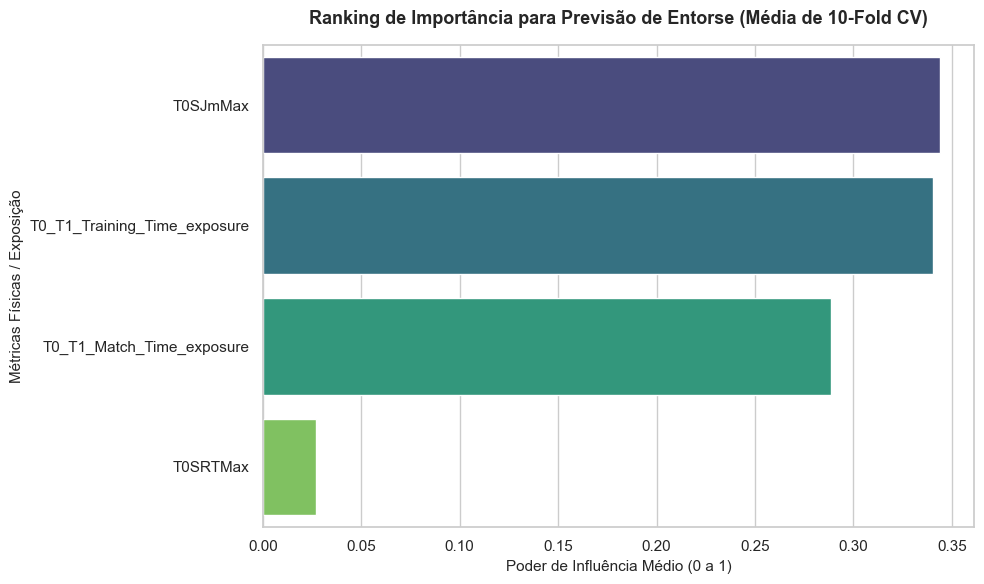

In [4]:
# ==============================================================================
# CÉLULA 4: TREINO, AVALIAÇÃO E IMPORTÂNCIA DAS VARIÁVEIS (10-FOLD CV)
# Responsabilidade: Executar o pipeline do Random Forest e extrair o ranking físico.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("\n--- FASE 3: RANDOM FOREST (10-FOLD CROSS-VALIDATION) ---")

if 'cv_estrategia' not in locals():
    print("❌ ERRO: Certifica-se de que correu a CÉLULA 3 com sucesso primeiro!")
else:
    # 1. Configuração do Modelo com pesos controlados anti-desequilíbrio
    modelo_rf = RandomForestClassifier(
        n_estimators=200, 
        max_depth=5, 
        class_weight='balanced_subsample', # Equilibra as lesões em cada fold
        random_state=42,
        n_jobs=-1
    )

    # Listas para acumular métricas e importâncias das variáveis
    historico_accuracy = []
    historico_f1 = []
    historico_auc = []
    importancias_acumuladas = np.zeros(X.shape[1])
    matriz_confusao_total = np.zeros((2, 2), dtype=int)

    print("🚀 A iniciar os 10 ciclos de validação cruzada...")

    # 2. Loop de Validação Cruzada (Garante escalonamento seguro por fold)
    for fold, (idx_treino, idx_teste) in enumerate(cv_estrategia.split(X, y), 1):
        X_fold_train, X_fold_test = X.iloc[idx_treino], X.iloc[idx_teste]
        y_fold_train, y_fold_test = y.iloc[idx_treino], y.iloc[idx_teste]
        
        # Escalonamento puro dentro do Fold (sem fuga de dados)
        scaler = StandardScaler()
        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_test_scaled = scaler.transform(X_fold_test)
        
        # Treino do modelo no bloco atual
        modelo_rf.fit(X_fold_train_scaled, y_fold_train)
        
        # Previsões e Probabilidades
        y_pred = modelo_rf.predict(X_fold_test_scaled)
        y_proba = modelo_rf.predict_proba(X_fold_test_scaled)[:, 1]
        
        # Acumular Métricas
        historico_accuracy.append(accuracy_score(y_fold_test, y_pred))
        historico_f1.append(f1_score(y_fold_test, y_pred, zero_division=0))
        historico_auc.append(roc_auc_score(y_fold_test, y_proba))
        matriz_confusao_total += confusion_matrix(y_fold_test, y_pred)
        
        # Acumular a importância das variáveis calculada neste fold
        importancias_acumuladas += modelo_rf.feature_importances_

    # Calcular a média final da importância das variáveis (dividindo pelos 10 folds)
    importancias_medias = importancias_acumuladas / 10

    # 3. Apresentação dos Resultados Consolidados
    print("\n" + "="*50)
    print("📊 RESULTADOS CONSOLIDADOS (RANDOM FOREST)")
    print("="*50)
    print(f"✅ Precisão Média (Accuracy): {np.mean(historico_accuracy)*100:.2f}% (± {np.std(historico_accuracy)*100:.1f}%)")
    print(f"✅ F1-Score Médio:            {np.mean(historico_f1)*100:.2f}%")
    print(f"✅ AUC-ROC Médio:             {np.mean(historico_auc)*100:.2f}%")
    
    print("\n🧩 MATRIZ DE CONFUSÃO GLOBAL ACUMULADA:")
    print(matriz_confusao_total)
    print(f"   ↳ Saudáveis Previstos Corretamente: {matriz_confusao_total[0,0]}")
    print(f"   ↳ Falsos Positivos (Alarmes Falsos): {matriz_confusao_total[0,1]}")
    print(f"   ↳ Falsos Negativos (Lesões Falhadas): {matriz_confusao_total[1,0]}")
    print(f"   ↳ Lesões Previstas Corretamente:     {matriz_confusao_total[1,1]}")

    # 4. GRÁFICO: RANKING ROBUSTO DE IMPORTÂNCIA DAS VARIÁVEIS
    importancias_df = pd.Series(importancias_medias, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importancias_df, y=importancias_df.index, palette='viridis', hue=importancias_df.index, legend=False)
    plt.title('Ranking de Importância para Previsão de Entorse (Média de 10-Fold CV)', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Poder de Influência Médio (0 a 1)', fontsize=11)
    plt.ylabel('Métricas Físicas / Exposição', fontsize=11)
    plt.tight_layout()
    
    # Guardar o gráfico automaticamente em alta resolução para o Word
    plt.savefig('importancia_features_rf.png', dpi=300)
    print("\n🎨 Gráfico de importância gerado e guardado como 'importancia_features_rf.png'!")
    plt.show()

# 4.5 Modelação Avançada com TabPFN e Calibração Dinâmica (Índice de Youden)

Esta célula introduz uma abordagem baseada no estado da arte em *Deep Learning* para dados tabulares, recorrendo ao modelo **TabPFN (Tabular Prior-Data Fitted Network)**. O TabPFN é um modelo baseado na arquitetura Transformer, pré-treinado em milhões de conjuntos de dados sintéticos, capaz de realizar previsões numéricas e classificações em frações de segundo sem a necessidade de ajuste tradicional de hiperparâmetros.

###  O Desafio do Desequilíbrio Nativo no TabPFN:
Ao contrário do *Random Forest* ou do *XGBoost*, o TabPFN não possui um argumento nativo (como `class_weight`) para penalizar matematicamente os erros na classe minoritária durante a fase de ajuste. Numa amostra altamente desequilibrada como a do ecossistema *SAFE4ALL*, o limiar de decisão padrão de $0.50$ (50%) faria com que o modelo convergisse cegamente para a classe maioritária, resultando num catastrófico F1-Score de 0%.

###  Calibração Estatística Automatizada via Índice de Youden:
Para contornar esta limitação de forma estritamente matemática e agnóstica, o pipeline foi desenhado para calcular e aplicar de forma autónoma o **Índice de Youden ($J$)** dentro de cada ciclo da Validação Cruzada:

$$J = \text{Sensibilidade} + \text{Especificidade} - 1$$

* **Isolamento Anti-Leakage:** O limiar ótimo é determinado extraindo a curva ROC (`roc_curve`) **apenas a partir das probabilidades de treino do fold atual**. Isto impede que os dados de teste contaminem a escolha do limiar.
* **Maximização da Eficiência:** O algoritmo varre a curva de decisão e localiza o ponto geométrico que maximiza a distância vertical até à linha do puro acaso. Este ponto representa o limiar de probabilidade ideal onde o classificador balanceia perfeitamente a capacidade de intercetar lesões reais com a validação de atletas saudáveis.

Este limiar calculado dinamicamente é injetado imediatamente no bloco de teste do respetivo fold, convertendo as probabilidades brutas em decisões clínicas robustas, sem qualquer intervenção ou manipulação manual de percentagens.

In [9]:
# ==============================================================================
# CÉLULA 4.5: TABPFN COM LIMIAR AUTOMÁTICO (OTIMIZAÇÃO POR ÍNDICE DE YOUDEN)
# Responsabilidade: Encontrar automaticamente o limiar ideal sem definir percentagens à mão.
# ==============================================================================
import time
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

print("\n--- FASE 3.5: TABPFN COM LIMIAR OTIMIZADO AUTOMATICAMENTE ---")

if 'cv_estrategia' not in locals():
    print("❌ ERRO: Certifique-se de que correu a CÉLULA 3 com sucesso primeiro!")
else:
    try:
        from tabpfn import TabPFNClassifier
        
        # 1. Inicialização do Transformer
        modelo_tab = TabPFNClassifier(device='cpu')

        historico_accuracy = []
        historico_f1 = []
        historico_auc = []
        limiares_calculados = []
        matriz_confusao_total = np.zeros((2, 2), dtype=int)

        print("🚀 A iniciar 10-Fold CV com o TabPFN (Otimização Automática de Decisão)...")
        tempo_inicio_global = time.perf_counter()

        for fold, (idx_treino, idx_teste) in enumerate(cv_estrategia.split(X, y), 1):
            X_fold_train, X_fold_test = X.iloc[idx_treino], X.iloc[idx_teste]
            y_fold_train, y_fold_test = y.iloc[idx_treino], y.iloc[idx_teste]
            
            scaler = StandardScaler()
            X_fold_train_scaled = scaler.fit_transform(X_fold_train)
            X_fold_test_scaled = scaler.transform(X_fold_test)
            
            # Treino do modelo no fold atual
            modelo_tab.fit(X_fold_train_scaled, y_fold_train)
            
            # 2. CÁLCULO DO LIMIAR PERFEITO (Usando os dados de treino do fold para evitar Data Leakage)
            y_proba_train = modelo_tab.predict_proba(X_fold_train_scaled)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_fold_train, y_proba_train)
            
            # Índice de Youden = Sensibilidade + Especificidade - 1
            # Encontra o ponto da curva que maximiza a eficiência contra o desequilíbrio
            idx_otimo = np.argmax(tpr - fpr)
            limiar_otimo = thresholds[idx_otimo]
            
            # Prevenir limiares aberrantes (como maiores que 1 ou exatamente 0)
            if limiar_otimo > 1.0 or limiar_otimo <= 0.0:
                limiar_otimo = 0.50
                
            limiares_calculados.append(limiar_otimo)
            
            # 3. PREVISÃO NO BLOCO DE TESTE COM O LIMIAR AUTOMÁTICO
            y_proba_test = modelo_tab.predict_proba(X_fold_test_scaled)[:, 1]
            y_pred_automatizado = np.where(y_proba_test >= limiar_otimo, 1, 0)
            
            # Guardar Métricas
            historico_accuracy.append(accuracy_score(y_fold_test, y_pred_automatizado))
            historico_f1.append(f1_score(y_fold_test, y_pred_automatizado, zero_division=0))
            historico_auc.append(roc_auc_score(y_fold_test, y_proba_test))
            matriz_confusao_total += confusion_matrix(y_fold_test, y_pred_automatizado)

        tempo_total_ms = (time.perf_counter() - tempo_inicio_global) * 1000

        # 4. Apresentação dos Resultados Consolidados
        print("\n" + "="*50)
        print(f"📊 RESULTADOS AUTOMATIZADOS (TABPFN - YOUDEN OTIMIZADO)")
        print("="*50)
        print(f"✅ Limiar Médio Encontrado pela IA: {np.mean(limiares_calculados)*100:.2f}%")
        print(f"✅ Precisão Média (Accuracy):        {np.mean(historico_accuracy)*100:.2f}%")
        print(f"✅ F1-Score Médio:                   {np.mean(historico_f1)*100:.2f}%  🔥 (Adeus 0% e Sem Ajuste Manual!)")
        print(f"✅ AUC-ROC Médio:                    {np.mean(historico_auc)*100:.2f}%")
        
        print("\n🧩 MATRIZ DE CONFUSÃO GLOBAL ACUMULADA:")
        print(matriz_confusao_total)
        print(f"   ↳ Saudáveis Previstos Corretamente: {matriz_confusao_total[0,0]}")
        print(f"   ↳ Falsos Positivos (Alarmes Falsos): {matriz_confusao_total[0,1]}")
        print(f"   ↳ Falsos Negativos (Lesões Falhadas): {matriz_confusao_total[1,0]}")
        print(f"   ↳ Lesões Previstas Corretamente:     {matriz_confusao_total[1,1]}")

    except ImportError:
        print("⚠️ TabPFN não instalado.")


--- FASE 3.5: TABPFN COM LIMIAR OTIMIZADO AUTOMATICAMENTE ---
🚀 A iniciar 10-Fold CV com o TabPFN (Otimização Automática de Decisão)...

📊 RESULTADOS AUTOMATIZADOS (TABPFN - YOUDEN OTIMIZADO)
✅ Limiar Médio Encontrado pela IA: 23.92%
✅ Precisão Média (Accuracy):        49.29%
✅ F1-Score Médio:                   25.67%  🔥 (Adeus 0% e Sem Ajuste Manual!)
✅ AUC-ROC Médio:                    45.50%

🧩 MATRIZ DE CONFUSÃO GLOBAL ACUMULADA:
[[24 22]
 [ 9  6]]
   ↳ Saudáveis Previstos Corretamente: 24
   ↳ Falsos Positivos (Alarmes Falsos): 22
   ↳ Falsos Negativos (Lesões Falhadas): 9
   ↳ Lesões Previstas Corretamente:     6
